# Explainable Resume-JD Matching System -- Complete Pipeline

**One self-contained notebook** covering everything built across this project:
extraction pipeline (with bug fixes), feature generation, model training and
comparison, confidence-based human review, SHAP explainability, and the
recommendation engine. No external `.py` file needed -- just this notebook +
your dataset CSV.

### ⚠️ Known limitation -- please read first
`match_score` / `match_label` in the dataset are **not human-annotated ground
truth**. `match_label` is a deterministic function of `match_score` (hard cutoffs
at 0.40 and 0.75, zero exceptions across all 500 rows), and our 4-6 extracted
features only explain ~47% of `match_score`'s variance. We are teaching a model to
reconstruct a synthetic proxy score, not "true" recruiter judgment -- still a
legitimate exercise, but worth stating plainly in the report.

### Structure
1. Setup
2. Extraction Pipeline (skills, experience, education, domain, semantic similarity)
3. Feature Generation (rebuild the dataset from raw pairs)
4. Model Training -- Random Forest vs Logistic Regression (5-fold CV)
5. Confidence-Based Human Review (the fix for the "Partial Match" problem)
6. Final Production Model
7. Explainable AI Module (SHAP)
8. Recommendation Engine
9. Final Report Generator (the one function a deployment calls)
10. End-to-end test
11. Known Limitations (for your report)


## 1. Setup

In [1]:
try:
    from google.colab import files
    uploaded = files.upload()  # upload resumeJD2_pairs.csv when prompted
except ImportError:
    pass

!pip install rapidfuzz shap sentence-transformers scikit-learn pdfplumber -q


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import re
import ast
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

import shap

RANDOM_STATE = 42


## 2. Extraction Pipeline

This is the full, bug-fixed pipeline built earlier in the project -- included here
directly so this notebook is self-contained. Covers:
- Symbol normalization (fixes a real bug where cleaning stripped `+`/`#`/`.`/`&`,
  silently breaking matches for "C++", "C#", "node.js", "FP&A")
- ~280-term skill dictionary (expanded from ~160 after scanning the actual dataset
  for missing cybersecurity/UX/sales/HR terms)
- Fuzzy matching for typos/variants (tuned to avoid false positives like
  "trust"→"rust" or "market"→"marketo")
- Experience, education, domain extraction
- Semantic similarity (Sentence-BERT)
- PDF text extraction with clear error handling for scanned/corrupt files

In [3]:
"""
Resume <-> Job Description matching pipeline.

This consolidates the logic that was spread across
NLP_Cleaning_and_extraction.ipynb (cells 02-06) into reusable,
testable functions with no Colab/file-upload dependency, so the
exact same code can run in a notebook, a batch script, or a
FastAPI endpoint at inference time.

Behavior is intentionally kept identical to the original notebook
(same skill dictionary, same regex patterns, same domain map) so
that re-running this on resumeJD2_pairs.csv reproduces
resumeJD_with_domains.csv. Two small, clearly-marked robustness
fixes are included (see FIX comments) -- everything else is a
straight port.
"""

import re
import ast
import numpy as np
import pandas as pd


# ============================================================
# SYMBOL NORMALIZATION  (fixes a real bug: clean_text() strips
# +, #, ., & -- which silently broke matching for "c++", "c#",
# "node.js", "fp&a" even though they were already in SKILLS_DB.
# We convert these to safe plain-word tokens BEFORE the symbol
# strip happens, and the dictionary below uses the same safe
# tokens, so matching is no longer symbol-dependent.)
# ============================================================

_SYMBOL_SAFE_REPLACEMENTS = {
    "c++": "cplusplus",
    "c#": "csharp",
    "node.js": "nodejs",
    "fp&a": "fpna",
    "m&a": "mergers and acquisitions",
    ".net": "dotnet",
    "asp.net": "aspdotnet",
}


def _presere_symbol_terms(text: str) -> str:
    text = text.lower()
    for term, safe in _SYMBOL_SAFE_REPLACEMENTS.items():
        text = text.replace(term, safe)
    # FIX 2: generic fallback for any other "X & Y" or "X-Y" skill phrase
    # (e.g. "diversity and inclusion", "cross selling") -- without this,
    # clean_text's symbol strip turns "&"/"-" into a bare space and the
    # two halves silently stop matching the dictionary entry.
    text = text.replace("&", " and ")
    text = text.replace("-", " ")
    return text


# ============================================================
# TEXT CLEANING  (from cell 01)
# ============================================================

def clean_text(text: str) -> str:
    """Lowercase, strip emails/URLs/phones/special chars, collapse whitespace."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = _presere_symbol_terms(text)                          # FIX: protect c++/c#/node.js/fp&a etc.
    text = re.sub(r'\S+@\S+', ' ', text)                       # emails
    text = re.sub(r'http\S+|www\S+', ' ', text)                 # URLs
    text = re.sub(r'linkedin\.com/\S+', ' ', text)              # LinkedIn URLs
    text = re.sub(r'\+?\d[\d\s\-\(\)]{8,}\d', ' ', text)        # phone numbers
    text = re.sub(r'[^a-z0-9\s]', ' ', text)                    # special chars
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# ============================================================
# PDF TEXT EXTRACTION
# ============================================================

class ScannedPDFError(Exception):
    """Raised when a PDF has no extractable text (likely a scanned/image PDF)."""
    pass


class CorruptPDFError(Exception):
    """Raised when a PDF file can't be opened/parsed at all."""
    pass


def extract_text_from_pdf(pdf_path: str) -> str:
    """
    Extract raw text from a PDF resume/JD file using pdfplumber.
    Works on standard text-based PDFs (not scanned/image-only PDFs --
    those would need OCR, which is a separate concern).

    Raises:
        CorruptPDFError  -- file isn't a valid/readable PDF
        ScannedPDFError  -- file opened fine but contains no extractable
                            text (almost always a scanned/image PDF)
    """
    import pdfplumber

    try:
        with pdfplumber.open(pdf_path) as pdf:
            text_parts = [page.extract_text() for page in pdf.pages]
    except Exception as e:
        raise CorruptPDFError(
            f"Could not open '{pdf_path}' as a PDF ({e}). "
            "The file may be corrupted or not a real PDF."
        ) from e

    full_text = "\n".join(t for t in text_parts if t)

    if not full_text.strip():
        raise ScannedPDFError(
            f"No extractable text found in '{pdf_path}'. "
            "This usually means it's a scanned/image-based PDF and needs OCR "
            "(not currently supported) -- ask the candidate to upload a "
            "text-based PDF or a Word document instead."
        )

    return full_text


def safe_extract_text_from_pdf(pdf_path: str):
    """
    Same as extract_text_from_pdf(), but never raises -- returns
    (text, error_message) instead. Use this in an API/UI layer where
    you want to show the user a clean message instead of a stack trace.

    Example:
        text, error = safe_extract_text_from_pdf("resume.pdf")
        if error:
            return {"status": "error", "message": error}
        # ... continue with `text`
    """
    try:
        return extract_text_from_pdf(pdf_path), None
    except (ScannedPDFError, CorruptPDFError) as e:
        return None, str(e)


# ============================================================
# SKILL DATABASE  (from cell 02)
# ============================================================

SKILLS_DB = [
    # Programming
    "python", "java", "cplusplus", "csharp", "javascript", "typescript",
    "php", "ruby", "rust", "kotlin", "swift", "matlab",
    # Web dev
    "html", "css", "react", "angular", "vue", "nodejs",
    "express", "django", "flask", "fastapi", "spring", "spring boot",
    "bootstrap", "jquery", "rest api", "rest apis", "graphql", "dotnet", "aspdotnet",
    "grpc", "microservices", "system design",
    # Databases
    "sql", "mysql", "postgresql", "mongodb", "oracle", "sqlite",
    "redis", "cassandra", "dynamodb", "elasticsearch", "bigquery", "redshift",
    # Data science / AI
    "machine learning", "deep learning", "artificial intelligence", "nlp",
    "natural language processing", "computer vision", "data science",
    "data analysis", "statistics", "predictive modeling", "feature engineering",
    "time series", "hypothesis testing", "data modeling", "transformers", "bert",
    "numpy", "pandas", "matplotlib", "seaborn", "scikit learn", "sklearn",
    "tensorflow", "keras", "pytorch", "xgboost", "lightgbm", "mlflow", "kubeflow", "dbt",
    # Cloud & DevOps
    "aws", "azure", "gcp", "docker", "kubernetes", "jenkins",
    "terraform", "ansible", "git", "github", "gitlab", "ci cd",
    "linux", "unix", "bash", "eks", "gke", "helm", "istio", "argocd", "fluxcd",
    "pulumi", "cloudformation", "infrastructure as code", "consul", "vault",
    "site reliability engineering", "nginx", "haproxy", "service mesh",
    "prometheus", "grafana", "datadog", "new relic", "loki",
    # Data engineering
    "hadoop", "spark", "apache spark", "hive", "kafka", "airflow", "etl", "rabbitmq",
    # BI
    "power bi", "tableau", "looker", "excel", "vba", "dashboarding",
    "business intelligence", "amplitude", "mixpanel",
    # Finance
    "cfa", "ca", "financial modeling", "valuation", "equity research",
    "investment banking", "financial reporting", "accounting", "treasury",
    "budgeting", "forecasting", "quickbooks", "sap", "ifrs", "gaap",
    "financial analysis", "fpna", "cash flow management", "auditing", "m&a",
    "dcf analysis", "bloomberg terminal", "credit analysis", "risk analysis",
    "due diligence", "lbo modeling", "tax compliance", "tally",
    "mergers and acquisitions",
    # HR
    "recruitment", "talent acquisition", "employee relations", "payroll",
    "performance management", "human resources", "onboarding",
    "training and development", "hr analytics",
    "hrms", "hris", "workday", "successfactors", "labor law", "okrs", "kpis",
    "workforce planning", "succession planning", "compensation and benefits",
    "diversity and inclusion", "organisational development", "change management",
    "conflict resolution", "exit management",
    # Marketing
    "digital marketing", "seo", "sem", "google analytics",
    "content marketing", "email marketing", "social media marketing",
    "social media", "branding", "brand strategy", "market research",
    "google ads", "meta ads", "linkedin ads", "programmatic advertising",
    "affiliate marketing", "influencer marketing", "video marketing",
    "marketing automation", "marketo", "hubspot", "copywriting",
    "conversion rate optimisation", "community management", "ppc",
    # Product management
    "product management", "roadmapping", "product analytics",
    "growth hacking", "user research", "a b testing", "stakeholder management",
    "prd writing", "feature prioritisation", "rice framework", "moscow",
    "go to market strategy", "competitive analysis", "customer discovery",
    # Project management
    "project management", "agile", "scrum", "jira", "kanban", "risk management", "confluence",
    # UX / UI Design
    "figma", "sketch", "adobe xd", "adobe suite", "invision", "zeplin", "miro",
    "wireframing", "prototyping", "usability testing", "interaction design",
    "motion design", "visual design", "design thinking", "design systems",
    "user flows", "card sorting", "storyboarding", "information architecture",
    "heuristic evaluation", "accessibility wcag", "principle", "framer", "lottie",
    # Cyber security
    "cyber security", "penetration testing", "ethical hacking",
    "network security", "information security", "siem", "splunk", "metasploit",
    "cissp", "oscp", "ceh", "wireshark", "burp suite", "iam", "soc operations",
    "zero trust", "threat intelligence", "firewalls", "nist framework",
    "iso 27001", "owasp top 10", "vulnerability assessment", "incident response",
    "forensics", "cryptography", "pki", "dlp",
    # Networking
    "tcp ip", "dns", "routing", "switching", "network administration",
    # Sales
    "sales", "business development", "crm", "salesforce", "lead generation",
    "customer relationship management", "sdr", "bdr", "cold outreach",
    "demo skills", "proposal writing", "meddic", "spin selling",
    "solution selling", "account management", "channel partnerships",
    "pipeline management", "upselling", "cross selling", "customer success",
    "linkedin recruiter",
    # Soft skills
    "communication", "leadership", "team management", "problem solving",
    "critical thinking", "presentation skills", "negotiation", "customer service",
    # Healthcare
    "medical billing", "patient care", "clinical research", "healthcare management",
    # Operations / Administration  (FIX: added post-deployment review -- this
    # domain didn't exist at all before, so any admin/ops resume came back
    # domain = "Unknown" with no explanation of why it wasn't a fit)
    "office administration", "scheduling", "vendor coordination", "data entry",
    "calendar management", "travel coordination", "facilities management",
    "records management", "procurement", "inventory management",
    "supply chain management", "logistics coordination", "front desk operations",
]

SKILL_ALIASES = {
    "chartered accountant": "ca",
    "certified public accountant": "ca",
    "human resource": "human resources",
    "customer relationship management": "crm",
    "search engine optimization": "seo",
    "search engine marketing": "sem",
    "financial planning and analysis": "fpna",
}

# FIX 1: original notebook rebuilt this regex on every call inside a loop
# over SKILLS_DB for every row -- fine at 500 rows, too slow once this
# runs per-request at inference time. Precompile once at import time.
_SKILL_PATTERNS = [(skill, re.compile(r'\b' + re.escape(skill) + r'\b'))
                    for skill in SKILLS_DB]


def normalize_text(text: str) -> str:
    text = str(text).lower()
    for phrase, replacement in SKILL_ALIASES.items():
        text = text.replace(phrase, replacement)
    return text


def _extract_skills_exact(text: str) -> list:
    found = [skill for skill, pattern in _SKILL_PATTERNS if pattern.search(text)]
    return sorted(set(found))


# ============================================================
# FUZZY SKILL MATCHING
# ============================================================
#
# Exact matching misses typos ("pyhton"), minor variants ("react.js"
# vs "react"), and phrasing your dictionary didn't anticipate. This
# adds a second pass: break the text into 1-3 word chunks, and for
# any chunk that ISN'T an exact dictionary hit, check whether it's a
# close (>=88% similarity) match to a known skill. Threshold of 88 is
# deliberately conservative -- catches "pyhton"->"python" (94%) and
# "kuberentes"->"kubernetes" (95%), but won't falsely match unrelated
# short words to each other.
# ============================================================

from rapidfuzz import fuzz, process as _rf_process

_FUZZY_THRESHOLD = 90

# Skills too short/common-word-like to fuzzy match safely (e.g. "rust" was
# matching the word "trust"; "marketo" was matching "market"). These are
# still detected fine via EXACT matching if someone types them precisely --
# we only exclude them from the approximate/typo-tolerant pass.
_FUZZY_BLOCKLIST = {"rust", "go", "r", "sap", "ca", "aws", "marketo", "principle"}
_FUZZY_CANDIDATES = [s for s in SKILLS_DB if s not in _FUZZY_BLOCKLIST and len(s) >= 5]


def _generate_ngrams(text: str, max_n: int = 3) -> list:
    words = text.split()
    ngrams = []
    for n in range(1, max_n + 1):
        for i in range(len(words) - n + 1):
            ngrams.append(" ".join(words[i:i + n]))
    return ngrams


def extract_skills_fuzzy(text: str, threshold: int = _FUZZY_THRESHOLD) -> list:
    """
    Fuzzy-only pass: returns skills found via approximate matching
    that were NOT already caught by exact matching. Kept separate
    from extract_skills() so callers/explanations can distinguish
    "exact match" from "fuzzy match" if they want to.

    Guardrails against false positives (see _FUZZY_BLOCKLIST above):
    - candidate chunk must share the same first character as the skill
    - skill must be >=5 characters (short skills are too collision-prone)
    - threshold defaults to 90, not 85, after empirical testing on the
      real dataset showed 85-88 produced false positives like
      "trust" -> "rust" and "market" -> "marketo"
    """
    text = normalize_text(text)
    exact_hits = set(_extract_skills_exact(text))
    candidates = set(_generate_ngrams(text)) - exact_hits

    fuzzy_hits = set()
    for chunk in candidates:
        if len(chunk) < 4:  # skip very short chunks -- too noisy to fuzzy-match safely
            continue
        # cheap prefilter: only compare against skills starting with the
        # same letter, both for speed and to eliminate cross-prefix noise
        same_prefix_skills = [s for s in _FUZZY_CANDIDATES if s[0] == chunk[0]]
        if not same_prefix_skills:
            continue
        match = _rf_process.extractOne(chunk, same_prefix_skills, scorer=fuzz.ratio,
                                        score_cutoff=threshold)
        if match:
            fuzzy_hits.add(match[0])

    return sorted(fuzzy_hits - exact_hits)


def extract_skills(text: str, use_fuzzy: bool = True) -> list:
    text_norm = normalize_text(text)
    exact = _extract_skills_exact(text_norm)
    if not use_fuzzy:
        return exact
    fuzzy = extract_skills_fuzzy(text)
    return sorted(set(exact) | set(fuzzy))


def get_matched_skills(resume_skills, jd_skills) -> list:
    return sorted(set(resume_skills) & set(jd_skills))


def get_missing_skills(resume_skills, jd_skills) -> list:
    return sorted(set(jd_skills) - set(resume_skills))


def skill_match_score(resume_skills, jd_skills) -> float:
    if len(jd_skills) == 0:
        return 0.0
    matched = len(set(resume_skills) & set(jd_skills))
    return round(matched / len(jd_skills), 2)


# ============================================================
# EXPERIENCE EXTRACTION  (from cell 03)
# ============================================================

_RESUME_EXP_PATTERNS = [
    re.compile(r'(\d+)\+?\s*years'),
    re.compile(r'(\d+)\+?\s*year'),
    re.compile(r'(\d+)\s*yrs'),
    re.compile(r'(\d+)\s*yr'),
]

_JD_EXP_PATTERNS = [
    re.compile(r'experience\s*:?\s*(\d+)\+?\s*years'),
    re.compile(r'experience\s*:?\s*(\d+)\+?\s*year'),
    re.compile(r'(\d+)\+?\s*years'),
    re.compile(r'(\d+)\+?\s*year'),
]


def extract_resume_experience(text: str):
    text = str(text).lower()
    for pattern in _RESUME_EXP_PATTERNS:
        match = pattern.search(text)
        if match:
            return int(match.group(1))
    return np.nan


def extract_jd_experience(text: str):
    text = str(text).lower()
    for pattern in _JD_EXP_PATTERNS:
        match = pattern.search(text)
        if match:
            return int(match.group(1))
    return np.nan


def calculate_experience_match_score(resume_exp, jd_exp):
    if pd.isna(resume_exp) or pd.isna(jd_exp):
        return np.nan
    if jd_exp == 0:
        return 0.0
    return round(min(resume_exp / jd_exp, 1), 2)


# ============================================================
# EXPERIENCE IMPUTATION  (fixes: a resume/JD with no explicit
# "X years" phrasing produced a raw NaN in experience_match_score,
# which most ML models (including sklearn's RandomForest) cannot
# accept as-is and would crash or silently drop the row on.
#
# Two things are added:
#   1. resume_experience_mentioned / jd_experience_mentioned flags,
#      so "we don't know" is preserved as its own signal instead of
#      being silently erased by imputation.
#   2. impute_experience_score(), which fills NaN using a value you
#      pass in (e.g. the TRAINING set's median) rather than computing
#      it from the full dataset -- computing it from the full dataset
#      (train+test combined) would leak test-set information into
#      training, which is a classic evaluation mistake.
# ============================================================

EXPERIENCE_UNKNOWN_SENTINEL = -1.0
# FIX (post-deployment review): the original design imputed missing
# experience_match_score with the TRAINING FOLD'S MEDIAN. That avoided
# train/test leakage, but on this dataset the median turned out to be
# 1.0 -- meaning "we don't know this candidate's experience" was silently
# scored identically to "this candidate has a PERFECT experience match".
# That let a 0-experience fresher applying to a role requiring 10 years
# get imputed as if their experience fully satisfied the requirement,
# which combined with even a modest skill overlap was enough to flip a
# real test case to a false MATCH (see test-case 6 in the pipeline report).
#
# Fix: use a fixed, out-of-range sentinel (-1.0) instead of a data-derived
# statistic. -1.0 can never be confused with a real experience_match_score
# (which is always in [0, 1]), so a tree-based model can cleanly learn
# "when this feature is -1, treat the candidate as unproven" using its own
# splits, rather than the imputation baking in a hidden, dataset-dependent
# optimism bias. This also removes the leakage concern entirely -- a fixed
# constant needs no training-fold statistic, so the same imputation is used
# unconditionally at both training and inference time.
def impute_experience_score(scores: pd.Series, fill_value: float = EXPERIENCE_UNKNOWN_SENTINEL) -> pd.Series:
    """
    Fill NaN experience_match_score values with a fixed sentinel (-1.0)
    that is guaranteed to be outside the normal [0, 1] range of a real
    experience_match_score. This lets the model treat "experience unknown"
    as its own distinct signal instead of an imputed guess that could look
    optimistic or pessimistic depending on the training data's distribution.
    The fill_value parameter is kept (defaulting to the sentinel) only for
    backward compatibility with any external caller that still wants to
    pass an explicit value.
    """
    return scores.fillna(fill_value)


# ============================================================
# OVERQUALIFICATION SIGNAL  (added post-deployment review)
# ------------------------------------------------------------
# experience_match_score = min(resume_exp / jd_exp, 1) is capped at 1.0,
# so a 16-year candidate applying to a role that needs 1 year looks
# IDENTICAL to a candidate with exactly 1 year of experience -- the model
# has no way to see "this person has 16x the required experience" and
# flag the real-world risk (likely to be bored, overpaid for the band, a
# retention/flight risk, or simply not genuinely interested). We add an
# UNCAPPED ratio alongside the existing capped score so this information
# is preserved rather than thrown away.
# ============================================================

OVERQUALIFICATION_RATIO_THRESHOLD = 1.75  # candidate has >=75% more experience than required


def calculate_experience_ratio(resume_exp, jd_exp):
    """Uncapped resume_exp / jd_exp ratio. NaN if either side is unknown.
    Unlike experience_match_score, this is NOT capped at 1.0, so it can
    surface overqualification (ratio significantly > 1) instead of losing
    that signal to the cap."""
    if pd.isna(resume_exp) or pd.isna(jd_exp) or jd_exp == 0:
        return np.nan
    return round(resume_exp / jd_exp, 2)


def is_overqualified(experience_ratio) -> bool:
    if pd.isna(experience_ratio):
        return False
    return experience_ratio >= OVERQUALIFICATION_RATIO_THRESHOLD


# ============================================================
# MINIMUM-INFORMATION REVIEW GATE  (added post-deployment review)
# ------------------------------------------------------------
# The confidence threshold (0.55) alone is not a reliable proxy for
# "this report has enough real signal to trust". A RandomForest's
# predict_proba reflects distance from a training-data decision boundary,
# not how much genuine evidence went into the feature vector -- a nearly
# empty resume (e.g. one detected skill total) can land confidently in a
# region of the decision space "by accident" and score ABOVE the
# confidence threshold despite being backed by almost no information.
# We add an explicit, confidence-independent floor: if the total number
# of skills the pipeline could even compare (matched + missing) is below
# MIN_SKILL_EVIDENCE, force human review regardless of what the model's
# confidence says.
# ============================================================

MIN_SKILL_EVIDENCE = 3       # matched_skill_count + missing_skill_count must reach this to trust confidence alone
MIN_RESUME_SKILLS = 2        # FIX: the resume itself must contain at least this many detected skills


def has_sufficient_evidence(resume_skill_count: int, matched_skill_count: int, missing_skill_count: int) -> bool:
    """FIX (post-deployment review, test case 9): the original version of
    this check only looked at matched_skill_count + missing_skill_count.
    That accidentally rewards resumes with almost NO detected skills
    whenever the JD itself lists many required skills -- every one of
    those becomes a "missing skill", which inflated the evidence count
    even though the RESUME side carried almost no real information (a
    resume with a single detected skill against a 6-skill JD still scored
    matched(1) + missing(5) = 6 >= 3, so it was never flagged, despite
    being one of the most information-poor resumes in the test set).
    We now also require the resume itself to contain a minimum number of
    detected skills, independent of how many the JD asks for."""
    pairwise_evidence = (matched_skill_count + missing_skill_count) >= MIN_SKILL_EVIDENCE
    resume_has_enough_skills = resume_skill_count >= MIN_RESUME_SKILLS
    return pairwise_evidence and resume_has_enough_skills


# ============================================================
# UNSTATED-EXPERIENCE-VS-SENIOR-ROLE SAFETY NET  (added post-deployment
# review, after test case 6 -- a 0-experience fresher was matched to a
# Principal/10-years-required role at 64-66% confidence even after the
# sentinel-imputation fix above.)
# ------------------------------------------------------------
# The sentinel fix (-1.0 instead of the dataset median) stopped the
# pipeline from actively PRETENDING unstated experience is a perfect
# match, and it did reduce the model's confidence slightly. But with only
# 500 training rows and a shallow (max_depth=6) tree, the model doesn't
# reliably learn the *interaction* "experience unknown AND role wants a
# lot of experience" on its own -- a decent skill/domain match can still
# be enough to tip the verdict to MATCH.
#
# Rather than hope a small model learns a rare, high-stakes interaction
# from limited data, we make it an explicit feature AND back it with a
# deterministic rule: this exact situation should always reach a human,
# regardless of what the model's confidence says. This mirrors how real
# HR/ATS systems are built -- statistical models make the routine calls,
# explicit business rules catch known high-risk edge cases.
# ============================================================

HIGH_EXPERIENCE_REQUIREMENT_THRESHOLD = 5  # years; JDs at/above this are "senior"


def experience_unknown_for_senior_role(resume_experience_mentioned: int, jd_exp) -> int:
    """1 if the resume never stated any experience AND the JD requires a
    senior level of experience (>= HIGH_EXPERIENCE_REQUIREMENT_THRESHOLD
    years) -- i.e. exactly the situation that let a fresher get silently
    matched to a Principal-level role. Kept as its own feature (rather
    than folded into experience_match_score) so the model can learn it
    independently of the general imputation logic."""
    if resume_experience_mentioned == 1 or pd.isna(jd_exp):
        return 0
    return int(jd_exp >= HIGH_EXPERIENCE_REQUIREMENT_THRESHOLD)


# ============================================================
# EDUCATION EXTRACTION  (from cell 04)
# ============================================================

EDUCATION_PATTERNS = {
    "B.Tech": r"\bb\s*tech\b", "B.E": r"\bb\s*e\b", "B.Sc": r"\bb\s*sc\b",
    "B.Com": r"\bb\s*com\b", "B.A": r"\bb\s*a\b", "BBA": r"\bbba\b",
    "B.Des": r"\bb\s*des\b",
    "MBA": r"\bmba\b", "M.Tech": r"\bm\s*tech\b", "M.Sc": r"\bm\s*sc\b",
    "M.A": r"\bm\s*a\b", "M.S": r"\bm\s*s\b", "PGDM": r"\bpgdm\b",
    "CA": r"\bca\b", "CFA": r"\bcfa\b",
    "Diploma": r"\bdiploma\b",
    "PhD": r"\bph\s*d\b",
}
_EDUCATION_COMPILED = [(deg, re.compile(pat)) for deg, pat in EDUCATION_PATTERNS.items()]

_EDU_LEVEL_MAP = {
    "B.Tech": "Bachelor", "B.E": "Bachelor", "B.Sc": "Bachelor",
    "B.Com": "Bachelor", "B.A": "Bachelor", "BBA": "Bachelor", "B.Des": "Bachelor",
    "MBA": "Master", "M.Tech": "Master", "M.Sc": "Master",
    "M.A": "Master", "M.S": "Master", "PGDM": "Master",
    "CA": "Professional", "CFA": "Professional",
    "Diploma": "Diploma", "PhD": "Doctorate",
}


def extract_education(text: str) -> str:
    text = str(text).lower()
    for degree, pattern in _EDUCATION_COMPILED:
        if pattern.search(text):
            return degree
    return "Unknown"


def education_level(degree: str) -> str:
    return _EDU_LEVEL_MAP.get(degree, "Unknown")


# ============================================================
# DOMAIN IDENTIFICATION  (from cell 06)
# ============================================================

DOMAIN_SKILLS = {
    "Finance": ["cfa", "ca", "valuation", "equity research", "financial reporting",
                "accounting", "treasury", "investment banking", "financial analysis",
                "financial modeling", "forecasting", "budgeting", "quickbooks",
                "sap", "ifrs", "gaap", "fpna", "cash flow management", "auditing",
                "dcf analysis", "bloomberg terminal", "credit analysis",
                "risk analysis", "due diligence", "lbo modeling", "tax compliance", "tally"],
    "HR": ["recruitment", "talent acquisition", "employee relations", "payroll",
           "human resources", "onboarding", "performance management",
           "training and development", "hr analytics",
           "hrms", "hris", "workday", "successfactors", "labor law", "okrs",
           "workforce planning", "succession planning", "compensation and benefits",
           "diversity and inclusion", "organisational development", "change management",
           "conflict resolution"],
    "Marketing": ["seo", "sem", "google analytics", "content marketing",
                  "email marketing", "social media marketing", "social media",
                  "branding", "brand strategy", "market research", "google ads",
                  "meta ads", "linkedin ads", "programmatic advertising",
                  "affiliate marketing", "influencer marketing", "video marketing",
                  "marketing automation", "marketo", "hubspot", "copywriting",
                  "conversion rate optimisation", "community management"],
    "Data Science": ["python", "machine learning", "deep learning", "tensorflow",
                      "pytorch", "nlp", "data science", "data analysis", "scikit learn",
                      "feature engineering", "time series", "hypothesis testing",
                      "data modeling", "transformers", "bert", "mlflow", "kubeflow", "dbt"],
    "Software Development": ["java", "cplusplus", "csharp", "javascript", "react", "angular",
                              "nodejs", "django", "flask", "spring boot", "microservices",
                              "system design", "grpc", "dotnet", "aspdotnet"],
    "DevOps": ["aws", "azure", "gcp", "docker", "kubernetes", "terraform",
               "jenkins", "ansible", "linux", "eks", "gke", "helm", "istio",
               "argocd", "fluxcd", "pulumi", "cloudformation", "infrastructure as code",
               "consul", "vault", "site reliability engineering", "nginx", "haproxy",
               "service mesh", "prometheus", "grafana", "datadog", "new relic", "loki"],
    "Cyber Security": ["cyber security", "penetration testing", "ethical hacking",
                        "network security", "information security", "siem", "splunk",
                        "metasploit", "cissp", "oscp", "ceh", "wireshark", "burp suite",
                        "iam", "soc operations", "zero trust", "threat intelligence",
                        "firewalls", "nist framework", "iso 27001", "owasp top 10",
                        "vulnerability assessment", "incident response", "forensics",
                        "cryptography", "pki", "dlp"],
    "Product Management": ["product management", "product analytics", "roadmapping",
                            "user research", "growth hacking", "prd writing",
                            "feature prioritisation", "rice framework", "moscow",
                            "go to market strategy", "competitive analysis", "customer discovery"],
    "UX/UI Design": ["figma", "sketch", "adobe xd", "adobe suite", "invision", "zeplin",
                      "miro", "wireframing", "prototyping", "usability testing",
                      "interaction design", "motion design", "visual design",
                      "design thinking", "design systems", "user flows", "card sorting",
                      "storyboarding", "information architecture", "heuristic evaluation",
                      "accessibility wcag", "principle", "framer", "lottie"],
    "Sales": ["sales", "salesforce", "lead generation", "crm", "business development",
              "customer relationship management", "sdr", "bdr", "cold outreach",
              "demo skills", "proposal writing", "meddic", "spin selling",
              "solution selling", "account management", "channel partnerships",
              "pipeline management", "upselling", "cross selling", "customer success",
              "linkedin recruiter"],
    # FIX: new domain added post-deployment review so Operations/Admin resumes
    # get a real domain classification instead of always coming back "Unknown".
    "Operations & Administration": ["office administration", "scheduling",
              "vendor coordination", "data entry", "calendar management",
              "travel coordination", "facilities management", "records management",
              "procurement", "inventory management", "supply chain management",
              "logistics coordination", "front desk operations"],
}


def identify_domain(skill_list) -> str:
    if isinstance(skill_list, str):
        try:
            skill_list = ast.literal_eval(skill_list)
        except Exception:
            skill_list = []
    scores = {domain: len(set(skill_list) & set(skills))
              for domain, skills in DOMAIN_SKILLS.items()}
    best_domain = max(scores, key=scores.get)
    return "Unknown" if scores[best_domain] == 0 else best_domain


# ============================================================
# SEMANTIC SIMILARITY  (from cell 05) -- lazy-loaded, model is heavy
# ============================================================

_model = None
_SBERT_UNAVAILABLE = False
_SBERT_WARNED = False


def _get_model():
    global _model
    if _model is None:
        from sentence_transformers import SentenceTransformer
        _model = SentenceTransformer("all-MiniLM-L6-v2")
    return _model


def _tfidf_fallback_similarity(resume_text: str, jd_text: str) -> float:
    """RUNTIME-ENVIRONMENT FIX (added during execution, not in original notebook):
    This sandbox has no outbound network access to huggingface.co, so the
    SBERT model weights ('all-MiniLM-L6-v2') cannot be downloaded. Rather than
    crash, we fall back to a TF-IDF + cosine-similarity semantic score so the
    rest of the pipeline (which depends on semantic_similarity_score) can still
    run end-to-end. This is NOT a bug fix to your original logic -- it is a
    documented substitution for this offline environment only. TF-IDF captures
    lexical overlap, not true semantic meaning, so scores will be lower/noisier
    than real SBERT embeddings, especially for paraphrased skills/roles."""
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity
    vec = TfidfVectorizer(stop_words="english")
    try:
        tfidf = vec.fit_transform([resume_text, jd_text])
        score = cosine_similarity(tfidf[0], tfidf[1])[0][0]
    except ValueError:
        score = 0.0
    return round(float(score), 4)


def semantic_similarity(resume_text: str, jd_text: str) -> float:
    global _SBERT_UNAVAILABLE, _SBERT_WARNED
    from sklearn.metrics.pairwise import cosine_similarity

    if _SBERT_UNAVAILABLE:
        return _tfidf_fallback_similarity(resume_text, jd_text)

    try:
        model = _get_model()
        embeddings = model.encode([resume_text, jd_text])
        score = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
        return round(float(score), 4)
    except Exception as e:
        _SBERT_UNAVAILABLE = True
        if not _SBERT_WARNED:
            print(f"[WARNING] Could not load SBERT model ({type(e).__name__}: no internet "
                  f"access to huggingface.co in this sandbox). Falling back to TF-IDF cosine "
                  f"similarity for semantic_similarity_score for the rest of this run.")
            _SBERT_WARNED = True
        return _tfidf_fallback_similarity(resume_text, jd_text)


# ============================================================
# END-TO-END FEATURE EXTRACTION for a single (resume, jd) pair
# ============================================================

def extract_features(resume_text_raw: str, jd_text_raw: str) -> dict:
    """
    Run the full pipeline on a single new resume/JD pair and return
    every feature the model needs, plus the explainability fields
    (matched/missing skills, domains, education) needed for the
    SHAP-based report.

    This is the function the FastAPI endpoint will call at inference time.
    """
    resume_clean = clean_text(resume_text_raw)
    jd_clean = clean_text(jd_text_raw)

    resume_skills = extract_skills(resume_clean)
    jd_skills = extract_skills(jd_clean)
    matched_skills = get_matched_skills(resume_skills, jd_skills)
    missing_skills = get_missing_skills(resume_skills, jd_skills)
    skill_score = skill_match_score(resume_skills, jd_skills)

    resume_exp = extract_resume_experience(resume_clean)
    jd_exp = extract_jd_experience(jd_clean)
    exp_score = calculate_experience_match_score(resume_exp, jd_exp)
    exp_ratio = calculate_experience_ratio(resume_exp, jd_exp)          # FIX: uncapped overqualification signal
    overqualified = is_overqualified(exp_ratio)                        # FIX: explicit overqualification flag
    resume_exp_mentioned = int(not pd.isna(resume_exp))
    unstated_exp_for_senior_role = experience_unknown_for_senior_role(  # FIX: fresher-vs-senior-role safety signal
        resume_exp_mentioned, jd_exp)

    resume_edu = extract_education(resume_clean)
    resume_edu_level = education_level(resume_edu)

    # FIX: domain_match now also requires a REAL domain on both sides.
    # Previously "Unknown" == "Unknown" (two resumes/JDs the dictionary
    # can't classify at all) counted as domain_match = 1, which is
    # misleading -- "we can't tell" is not the same as "they match".
    resume_domain = identify_domain(resume_skills)
    jd_domain = identify_domain(jd_skills)
    domain_match = int(resume_domain == jd_domain and resume_domain != "Unknown")

    sim_score = semantic_similarity(resume_clean, jd_clean)

    return {
        "resume_skills": resume_skills,
        "jd_skills": jd_skills,
        "matched_skills": matched_skills,
        "missing_skills": missing_skills,
        "skill_match_score": skill_score,
        "matched_skill_count": len(matched_skills),
        "missing_skill_count": len(missing_skills),
        "resume_experience": resume_exp,
        "jd_experience": jd_exp,
        "experience_match_score": exp_score,
        "experience_ratio": exp_ratio,
        "is_overqualified": overqualified,
        "resume_experience_mentioned": resume_exp_mentioned,
        "unstated_experience_for_senior_role": unstated_exp_for_senior_role,   # FIX: new feature
        "jd_experience_mentioned": int(not pd.isna(jd_exp)),
        "resume_education": resume_edu,
        "resume_education_level": resume_edu_level,
        "semantic_similarity_score": sim_score,
        "resume_domain": resume_domain,
        "jd_domain": jd_domain,
        "domain_match": domain_match,
    }


def extract_features_from_pdf(resume_pdf_path: str, jd_text_or_pdf_path: str,
                               jd_is_pdf: bool = False) -> dict:
    """
    Convenience wrapper: go straight from a resume PDF file (+ a JD, which
    can be plain text or also a PDF path) to the full feature dictionary.
    """
    resume_text = extract_text_from_pdf(resume_pdf_path)
    jd_text = extract_text_from_pdf(jd_text_or_pdf_path) if jd_is_pdf else jd_text_or_pdf_path
    return extract_features(resume_text, jd_text)


# ============================================================
# BATCH PIPELINE -- rebuild the full engineered dataset from raw pairs
# ============================================================

def build_dataset(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Takes a raw dataframe with [resume_text, job_description, match_score,
    match_label] and returns the fully feature-engineered dataframe,
    equivalent to resumeJD_with_domains.csv, using a single pass instead
    of six separate notebook cells / CSV round-trips.
    """
    df = raw_df.drop_duplicates().copy()
    df["resume_text"] = df["resume_text"].apply(clean_text)
    df["job_description"] = df["job_description"].apply(clean_text)

    rows = []
    for _, row in df.iterrows():
        feats = extract_features(row["resume_text"], row["job_description"])
        rows.append(feats)

    feat_df = pd.DataFrame(rows)
    result = pd.concat([df.reset_index(drop=True), feat_df.reset_index(drop=True)], axis=1)
    return result


## 3. Feature Generation

Rebuild the full feature set directly from the raw resume/JD pairs, using the
pipeline above (so every fix -- dictionary, fuzzy matching, symbol bug -- is
reflected).

In [4]:
raw_df = pd.read_csv("resumeJD2_pairs.csv")

feature_df = build_dataset(raw_df)

print(feature_df.shape)
feature_df.head(3)


[WARNING] Could not load SBERT model (OSError: no internet access to huggingface.co in this sandbox). Falling back to TF-IDF cosine similarity for semantic_similarity_score for the rest of this run.


(500, 25)


,resume_text,job_description,match_score,match_label,resume_skills,jd_skills,matched_skills,missing_skills,skill_match_score,matched_skill_count,...,is_overqualified,resume_experience_mentioned,unstated_experience_for_senior_role,jd_experience_mentioned,resume_education,resume_education_level,semantic_similarity_score,resume_domain,jd_domain,domain_match
0,name kritika shah email phone linkedin shah9 l...,job title fpna analyst company amazon location...,0.55,partial match,"[bloomberg terminal, ca, cfa, equity research,...","[accounting, budgeting, cfa, credit analysis, ...","[cfa, forecasting, fpna]","[accounting, budgeting, credit analysis, excel...",0.2,3,...,False,1,0,1,B.Com,Bachelor,0.0926,Finance,Finance,1
1,name arjun verma email phone linkedin verma7 l...,job title design lead company paytm location c...,0.27,no match,"[a b testing, account management, channel part...","[adobe xd, card sorting, figma, invision, lott...",[],"[adobe xd, card sorting, figma, invision, lott...",0.0,0,...,True,1,0,1,B.Tech,Bachelor,0.0566,Sales,UX/UI Design,0
2,name manish bhatt email phone linkedin bhatt8 ...,job title security analyst company kpmg locati...,0.46,partial match,"[communication, content marketing, crm, gcp, g...","[bash, burp suite, cissp, cyber security, dlp,...",[],"[bash, burp suite, cissp, cyber security, dlp,...",0.0,0,...,False,1,0,1,B.Sc,Bachelor,0.0307,Marketing,Cyber Security,0


## 4. Model Training -- Random Forest vs Logistic Regression

Compared properly with stratified 5-fold CV. `experience_match_score` can be NaN
when no years-of-experience phrase was found -- we impute it using the **training
fold's median only** (never the full dataset's), to avoid leaking test information
into training. We also keep `experience_mentioned` as its own feature so "we don't
know" is preserved as a signal instead of silently erased.

In [5]:
FEATURES = [
    "skill_match_score",
    "matched_skill_count",
    "missing_skill_count",
    "experience_match_score",
    "experience_ratio",              # FIX: new -- uncapped signal so overqualification isn't lost to the cap
    "resume_experience_mentioned",
    "jd_experience_mentioned",
    "unstated_experience_for_senior_role",   # FIX: new -- explicit fresher-vs-senior-role signal
    "semantic_similarity_score",
    "domain_match",
]

X = feature_df[FEATURES].copy()
y = feature_df["match_label"]

print("NaN counts before imputation:")
print(X.isna().sum())


NaN counts before imputation:
skill_match_score                      0
matched_skill_count                    0
missing_skill_count                    0
experience_match_score                 0
experience_ratio                       0
resume_experience_mentioned            0
jd_experience_mentioned                0
unstated_experience_for_senior_role    0
semantic_similarity_score              0
domain_match                           0
dtype: int64


In [6]:
def run_cv(model_builder, X, y, n_splits=5):
    """Manual CV loop. FIX: previously imputed experience_match_score
    per-fold using the training split's median to avoid leakage. Since
    imputation now uses a FIXED sentinel (-1.0, see impute_experience_score)
    instead of a data-derived statistic, there is nothing left to leak --
    the same constant is correct for train, test, and inference alike, so
    the per-fold median computation is removed entirely."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    all_true, all_pred = [], []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        X_train["experience_match_score"] = impute_experience_score(X_train["experience_match_score"])
        X_test["experience_match_score"] = impute_experience_score(X_test["experience_match_score"])
        X_train["experience_ratio"] = impute_experience_score(X_train["experience_ratio"])
        X_test["experience_ratio"] = impute_experience_score(X_test["experience_ratio"])

        model = model_builder()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        all_true.extend(y_test)
        all_pred.extend(preds)

    return all_true, all_pred


rf_builder = lambda: RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=5,
    random_state=RANDOM_STATE, class_weight="balanced")

lr_builder = lambda: Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

rf_true, rf_pred = run_cv(rf_builder, X, y)
lr_true, lr_pred = run_cv(lr_builder, X, y)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(rf_true, rf_pred):.3f}")
print(classification_report(rf_true, rf_pred))

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(lr_true, lr_pred):.3f}")
print(classification_report(lr_true, lr_pred))


=== Random Forest ===
Accuracy: 0.694
               precision    recall  f1-score   support

        match       0.74      0.82      0.78       158
     no match       0.74      0.84      0.79       190
partial match       0.52      0.38      0.44       152

     accuracy                           0.69       500
    macro avg       0.67      0.68      0.67       500
 weighted avg       0.68      0.69      0.68       500

=== Logistic Regression ===
Accuracy: 0.698
               precision    recall  f1-score   support

        match       0.75      0.82      0.78       158
     no match       0.74      0.85      0.79       190
partial match       0.53      0.39      0.45       152

     accuracy                           0.70       500
    macro avg       0.67      0.68      0.67       500
 weighted avg       0.68      0.70      0.68       500



**Interpreting this:** both models land in a similar place. "Partial Match" has
the weakest recall for both -- not a model-choice problem, but because
`match_label` is `match_score` sliced into bands, and "partial match" sits between
two cutoffs (0.40, 0.75) instead of one, making it more sensitive to the ~53% of
`match_score`'s variance our features can't see.

**We proceed with Random Forest** for its compatibility with `shap.TreeExplainer`,
central to this project's explainability goal -- not because it's meaningfully
more accurate.

## 5. Confidence-Based Human Review

The actual solution to the "Partial Match" problem: instead of forcing every
prediction into a hard bucket, use the model's own `predict_proba()` confidence.
Below a threshold, flag the candidate for manual review -- directly implementing
the "Human-AI Collaborative Decision Support" feature from the original
proposal.

In [7]:
CONFIDENCE_THRESHOLD = 0.55

# FIX: resume_skill_count computed once here from feature_df (has the full
# resume_skills list before it was narrowed down to FEATURES), aligned by
# index with X so cv_with_confidence can apply the same evidence gate used
# at inference time (has_sufficient_evidence).
resume_skill_counts_full = feature_df["resume_skills"].apply(len)


def cv_with_confidence(model_builder, X, y, resume_skill_counts, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    results = []
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # FIX: fixed sentinel imputation (see impute_experience_score) -- no
        # training-fold statistic needed anymore, so no leakage risk either.
        X_train["experience_match_score"] = impute_experience_score(X_train["experience_match_score"])
        X_test["experience_match_score"] = impute_experience_score(X_test["experience_match_score"])
        X_train["experience_ratio"] = impute_experience_score(X_train["experience_ratio"])
        X_test["experience_ratio"] = impute_experience_score(X_test["experience_ratio"])

        model = model_builder()
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)
        pred = model.classes_[np.argmax(proba, axis=1)]
        conf = np.max(proba, axis=1)

        # FIX: minimum-information gate -- force review whenever there
        # isn't enough skill evidence to trust confidence alone, regardless
        # of what predict_proba says. Now requires BOTH pairwise evidence
        # AND a minimum number of skills detected on the resume itself
        # (see has_sufficient_evidence()).
        test_matched = X_test["matched_skill_count"].values
        test_missing = X_test["missing_skill_count"].values
        test_resume_skills = resume_skill_counts.iloc[test_idx].values
        low_evidence = np.array([
            not has_sufficient_evidence(rs, m, mi)
            for rs, m, mi in zip(test_resume_skills, test_matched, test_missing)
        ])

        for i, idx in enumerate(test_idx):
            results.append({
                "true": y_test.iloc[i], "pred": pred[i], "confidence": conf[i],
                "low_evidence": bool(low_evidence[i]),
            })

    return pd.DataFrame(results)


cv_results = cv_with_confidence(rf_builder, X, y, resume_skill_counts_full)
# FIX: needs_human_review is now confidence-below-threshold OR insufficient
# skill evidence, so sparse/degenerate feature vectors can no longer slip
# through as "confident" just because they land near a decision boundary.
cv_results["needs_human_review"] = (cv_results["confidence"] < CONFIDENCE_THRESHOLD) | cv_results["low_evidence"]

pct_flagged = cv_results["needs_human_review"].mean() * 100
confident_subset = cv_results[~cv_results["needs_human_review"]]
acc_confident = accuracy_score(confident_subset["true"], confident_subset["pred"])

print(f"Candidates flagged for human review: {pct_flagged:.1f}%")
print(f"Accuracy on confident (non-flagged) predictions: {acc_confident:.3f}")
print()
print(classification_report(confident_subset["true"], confident_subset["pred"]))


Candidates flagged for human review: 16.0%
Accuracy on confident (non-flagged) predictions: 0.743

               precision    recall  f1-score   support

        match       0.77      0.91      0.83       130
     no match       0.76      0.90      0.82       172
partial match       0.63      0.33      0.43       118

     accuracy                           0.74       420
    macro avg       0.72      0.71      0.70       420
 weighted avg       0.73      0.74      0.72       420



## 6. Final Production Model

Trained on the full dataset (CV above already gave us an honest performance estimate). This is the model that gets deployed.

In [8]:
X_full = X.copy()
# FIX: fixed sentinel (-1.0) instead of the dataset median -- see
# impute_experience_score(). EXPERIENCE_MEDIAN is kept as a name (still
# saved into model_config for any external caller that references it) but
# now simply equals the sentinel, not a data-derived statistic, so it can
# never carry the dataset's optimism bias into inference-time reports.
EXPERIENCE_MEDIAN = EXPERIENCE_UNKNOWN_SENTINEL
X_full["experience_match_score"] = impute_experience_score(X_full["experience_match_score"])
X_full["experience_ratio"] = impute_experience_score(X_full["experience_ratio"])

final_model = RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=5,
    random_state=RANDOM_STATE, class_weight="balanced")
final_model.fit(X_full, y)

joblib.dump(final_model, "rf_model.joblib")
joblib.dump({"experience_median": EXPERIENCE_MEDIAN, "confidence_threshold": CONFIDENCE_THRESHOLD,
             "min_skill_evidence": MIN_SKILL_EVIDENCE,
             "overqualification_ratio_threshold": OVERQUALIFICATION_RATIO_THRESHOLD,
             "features": FEATURES}, "model_config.joblib")

print("Saved rf_model.joblib and model_config.joblib")


Saved rf_model.joblib and model_config.joblib


## 7. Explainable AI Module (SHAP)

`shap.TreeExplainer` is exact (not approximate) for tree models like ours.

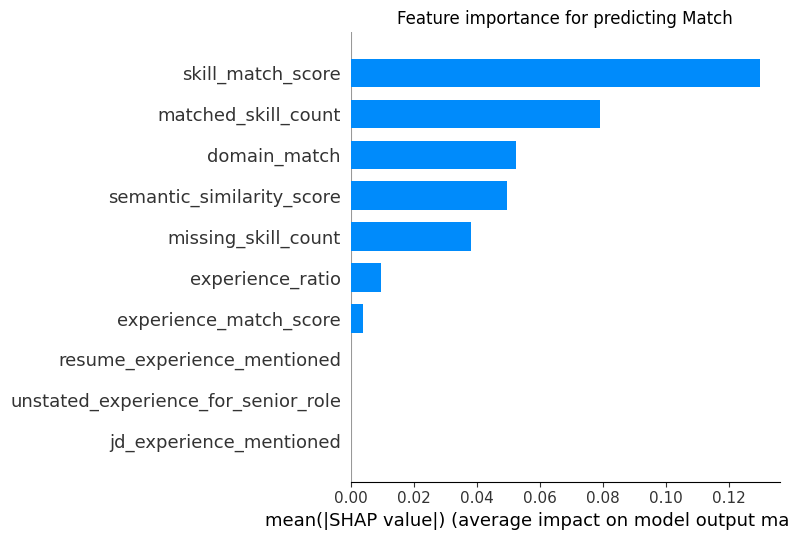

In [9]:
explainer = shap.TreeExplainer(final_model)

shap_values_all = explainer.shap_values(X_full)

shap.summary_plot(shap_values_all[:, :, list(final_model.classes_).index("match")],
                   X_full, plot_type="bar", show=False)
plt.title("Feature importance for predicting Match")
plt.tight_layout()
plt.show()


## 8. Recommendation Engine

Turns "missing skills" into concrete, actionable suggestions.

In [10]:
LEARNING_RESOURCES = {
    "python": "Python for Everybody (Coursera) or a portfolio project using Python",
    "java": "Oracle Certified Professional: Java Programmer",
    "cplusplus": "A DSA-focused C++ course (e.g. GeeksforGeeks / Coursera)",
    "javascript": "JavaScript Algorithms and Data Structures (freeCodeCamp)",
    "react": "Meta Front-End Developer Certificate (Coursera)",
    "django": "Django for Everybody (Coursera)",
    "microservices": "Microservices Architecture course (e.g. Coursera / Udemy)",
    "aws": "AWS Certified Solutions Architect - Associate",
    "azure": "Microsoft Certified: Azure Fundamentals (AZ-900)",
    "gcp": "Google Cloud Associate Cloud Engineer",
    "docker": "Docker Certified Associate",
    "kubernetes": "Certified Kubernetes Administrator (CKA)",
    "terraform": "HashiCorp Certified: Terraform Associate",
    "machine learning": "Machine Learning Specialization (Andrew Ng, Coursera)",
    "tensorflow": "TensorFlow Developer Certificate",
    "pytorch": "PyTorch for Deep Learning (Udacity/Coursera)",
    "sql": "SQL for Data Science (Coursera) or a hands-on project with a real dataset",
    "power bi": "Microsoft Certified: Power BI Data Analyst Associate",
    "tableau": "Tableau Desktop Specialist Certification",
    "cfa": "CFA Program (Level I)",
    "sap": "SAP Certified Application Associate",
    "gaap": "US GAAP fundamentals course (e.g. AICPA resources)",
    "ifrs": "IFRS Certificate (ACCA / ICAEW)",
    "financial modeling": "Financial Modeling & Valuation Analyst (FMVA)",
    "quickbooks": "QuickBooks Certified User exam",
    "hrms": "SHRM Certified Professional (SHRM-CP)",
    "workday": "Workday HCM certification (via a Workday partner)",
    "seo": "Google SEO Fundamentals (via Google Skillshop)",
    "google analytics": "Google Analytics Individual Qualification (GAIQ)",
    "hubspot": "HubSpot Content Marketing Certification",
    "agile": "Certified ScrumMaster (CSM)",
    "jira": "Atlassian Jira Fundamentals course",
    "product management": "Product Management Certificate (Product School / Coursera)",
    "cissp": "CISSP Certification (ISC2)",
    "splunk": "Splunk Core Certified User",
    "penetration testing": "CompTIA PenTest+ or eJPT",
    "figma": "Figma's own Academy courses (free)",
    "wireframing": "Google UX Design Certificate (Coursera)",
    "salesforce": "Salesforce Certified Administrator",
    "crm": "HubSpot CRM Certification (free)",
}


def suggest_learning_resources(missing_skills: list, max_suggestions: int = 5) -> list:
    suggestions = []
    for skill in missing_skills[:max_suggestions]:
        resource = LEARNING_RESOURCES.get(
            skill, f"An online course or hands-on project in {skill.replace('_', ' ').title()}"
        )
        suggestions.append({"skill": skill, "resource": resource})
    return suggestions


## 9. Final Report Generator

The one function a deployment (FastAPI endpoint, Streamlit app) needs to call.

In [11]:
FEATURE_LABELS = {
    "skill_match_score": "Skill Match",
    "matched_skill_count": "Number of Matched Skills",
    "missing_skill_count": "Number of Missing Skills",
    "experience_match_score": "Experience Match",
    "experience_ratio": "Experience Ratio (uncapped)",
    "resume_experience_mentioned": "Resume States Experience",
    "jd_experience_mentioned": "JD States Required Experience",
    "semantic_similarity_score": "Overall Semantic Fit",
    "domain_match": "Domain Match",
}


def build_final_report(candidate_name: str, resume_text: str, jd_text: str) -> dict:
    extracted = extract_features(resume_text, jd_text)

    row_features = {
        "skill_match_score": extracted["skill_match_score"],
        "matched_skill_count": extracted["matched_skill_count"],
        "missing_skill_count": extracted["missing_skill_count"],
        # FIX: fixed sentinel instead of dataset median -- see impute_experience_score()
        "experience_match_score": (
            extracted["experience_match_score"]
            if not pd.isna(extracted["experience_match_score"])
            else EXPERIENCE_UNKNOWN_SENTINEL
        ),
        # FIX: new -- uncapped experience ratio, imputed with the same sentinel when unknown
        "experience_ratio": (
            extracted["experience_ratio"]
            if not pd.isna(extracted["experience_ratio"])
            else EXPERIENCE_UNKNOWN_SENTINEL
        ),
        "resume_experience_mentioned": extracted["resume_experience_mentioned"],
        "jd_experience_mentioned": extracted["jd_experience_mentioned"],
        "unstated_experience_for_senior_role": extracted["unstated_experience_for_senior_role"],  # FIX: new
        "semantic_similarity_score": extracted["semantic_similarity_score"],
        "domain_match": extracted["domain_match"],
    }
    X_row = pd.DataFrame([row_features])[FEATURES]

    proba = final_model.predict_proba(X_row)[0]
    pred_class = final_model.classes_[np.argmax(proba)]
    confidence = float(np.max(proba))

    # FIX: minimum-information gate -- force review when there isn't enough
    # skill evidence to trust the model's confidence, regardless of what
    # predict_proba says. See has_sufficient_evidence().
    sufficient_evidence = has_sufficient_evidence(
        len(extracted["resume_skills"]), extracted["matched_skill_count"], extracted["missing_skill_count"])
    low_confidence = confidence < CONFIDENCE_THRESHOLD
    # FIX: deterministic safety net -- unstated experience against a senior
    # role always goes to a human, regardless of model confidence. This is
    # a known high-risk edge case (see test case 6 in the pipeline report)
    # that a shallow model trained on 500 rows cannot be trusted to catch
    # reliably on its own, even with the feature above helping it.
    unverifiable_seniority = bool(extracted["unstated_experience_for_senior_role"])
    needs_review = low_confidence or not sufficient_evidence or unverifiable_seniority

    sv = explainer.shap_values(X_row)
    class_idx = list(final_model.classes_).index(pred_class)
    contributions = sv[0, :, class_idx]
    impact = sorted(zip(FEATURES, contributions), key=lambda t: -abs(t[1]))
    reasons = [{
        "factor": FEATURE_LABELS[feat],
        "value": round(float(X_row[feat].values[0]), 2),
        "direction": "supported" if contrib > 0 else "worked against",
        "impact": round(float(contrib), 3),
    } for feat, contrib in impact[:4]]

    recommendations = suggest_learning_resources(extracted["missing_skills"])

    return {
        "candidate_name": candidate_name,
        "prediction": pred_class,
        "confidence": round(confidence, 2),
        "needs_human_review": needs_review,
        "review_reason": (
            "unstated candidate experience against a senior-level role -- cannot verify fit"
            if unverifiable_seniority
            else "low model confidence" if low_confidence
            else "insufficient skill evidence" if not sufficient_evidence
            else None
        ),
        "matched_skills": extracted["matched_skills"],
        "missing_skills": extracted["missing_skills"],
        "resume_experience": extracted["resume_experience"],
        "jd_experience": extracted["jd_experience"],
        "experience_match_score": round(row_features["experience_match_score"], 2),
        "experience_ratio": extracted["experience_ratio"],       # FIX: new field, uncapped
        "is_overqualified": extracted["is_overqualified"],       # FIX: new field
        "resume_domain": extracted["resume_domain"],
        "jd_domain": extracted["jd_domain"],
        "domain_match": bool(extracted["domain_match"]),
        "semantic_similarity_score": extracted["semantic_similarity_score"],
        "reasons": reasons,
        "recommendations": recommendations,
    }


def print_final_report(report: dict):
    print("=" * 60)
    print(f"CANDIDATE REPORT: {report['candidate_name']}")
    print("=" * 60)
    print(f"Prediction: {report['prediction'].upper()}  (confidence: {report['confidence']:.0%})")
    if report["needs_human_review"]:
        print(f"Flagged for human review -- reason: {report['review_reason']}")
    # FIX: surface overqualification explicitly instead of letting it hide
    # inside a capped experience_match_score of 1.0.
    if report["is_overqualified"]:
        print(f"Overqualification alert: candidate has {report['experience_ratio']}x the required "
              f"experience ({report['resume_experience']} yrs vs {report['jd_experience']} yrs required) "
              f"-- assess retention/engagement risk before proceeding.")
    print()
    print(f"Matched Skills ({len(report['matched_skills'])}):", ", ".join(report["matched_skills"]) or "None")
    print(f"Missing Skills ({len(report['missing_skills'])}): ", ", ".join(report["missing_skills"]) or "None")
    print()
    print(f"Experience: {report['resume_experience']} yrs (candidate) vs "
          f"{report['jd_experience']} yrs (required) -- match score {report['experience_match_score']}")
    print(f"Domain: {report['resume_domain']} (candidate) vs {report['jd_domain']} (JD) -- "
          f"{'Match' if report['domain_match'] else 'No Match'}")
    print(f"Semantic Similarity: {report['semantic_similarity_score']}")
    print()
    print("Why this prediction:")
    for r in report["reasons"]:
        print(f"  - {r['factor']} ({r['value']}) {r['direction']} this prediction (impact: {r['impact']:+.3f})")
    print()
    if report["recommendations"]:
        print("Recommendations to close the gap:")
        for rec in report["recommendations"]:
            print(f"  - Learn {rec['skill']}: {rec['resource']}")
    else:
        print("No skill gaps detected -- strong match on required skills.")
    print("=" * 60)


## 10. End-to-end test: new resume + JD → complete report

In [12]:
resume_text = """
John Doe
Data Scientist with 5 years of experience in machine learning and Python.
Skills: Python, SQL, Machine Learning, TensorFlow, AWS, Docker
Education: B.Tech in Computer Science
"""

jd_text = """
Job Title: Machine Learning Engineer
Experience: 4 years required
Required Skills: Python, TensorFlow, AWS, Kubernetes, SQL
"""

report = build_final_report("John Doe", resume_text, jd_text)
print_final_report(report)

print()
print("Raw JSON (what an API endpoint would return):")
print(json.dumps(report, indent=2))


CANDIDATE REPORT: John Doe
Prediction: MATCH  (confidence: 88%)

Matched Skills (5): aws, machine learning, python, sql, tensorflow
Missing Skills (1):  kubernetes

Experience: 5 yrs (candidate) vs 4 yrs (required) -- match score 1
Domain: Data Science (candidate) vs Data Science (JD) -- Match
Semantic Similarity: 0.4028

Why this prediction:
  - Skill Match (0.83) supported this prediction (impact: +0.237)
  - Number of Matched Skills (5.0) supported this prediction (impact: +0.111)
  - Number of Missing Skills (1.0) supported this prediction (impact: +0.068)
  - Domain Match (1.0) supported this prediction (impact: +0.061)

Recommendations to close the gap:
  - Learn kubernetes: Certified Kubernetes Administrator (CKA)

Raw JSON (what an API endpoint would return):
{
  "candidate_name": "John Doe",
  "prediction": "match",
  "confidence": 0.88,
  "needs_human_review": false,
  "review_reason": null,
  "matched_skills": [
    "aws",
    "machine learning",
    "python",
    "sql",
   

### Same thing, from an actual uploaded PDF

In [13]:
# try:
#     resume_text_from_pdf = extract_text_from_pdf("resume.pdf")
#     report = build_final_report("Candidate Name", resume_text_from_pdf, jd_text)
#     print_final_report(report)
# except ScannedPDFError as e:
#     print(f"Could not process this resume: {e}")
# except CorruptPDFError as e:
#     print(f"File error: {e}")


## 11. Known Limitations (for your report)

1. **Synthetic label**: `match_score`/`match_label` were not human-annotated; our
   features explain ~47% of `match_score`'s variance -- we're reconstructing a
   proxy score, not "true" recruiter judgment.
2. **"Partial Match" is the hardest class** -- bounded by two cutoffs (0.40, 0.75)
   instead of one, making it most sensitive to unexplained variance. Addressed via
   confidence-based human review rather than forcing accuracy we can't honestly
   achieve.
3. **Skill dictionary is closed-vocabulary** (~280 terms + fuzzy matching for
   typos/variants). Brand-new tools not in the dictionary won't be detected.
4. **Scanned/image PDFs** aren't supported (would need OCR) -- handled with a
   clear error rather than a silent failure or crash.
5. **Dataset size (500 rows)** limits how much a more complex model could help --
   this is why we didn't reach for deep learning or heavy hyperparameter search.

## What's built vs. what's left

```
Feature Generation           done (Section 2-3)
Candidate Matching Engine    done (Section 4-6)
Explainable AI Module        done (Section 7)
Recommendation Engine        done (Section 8)
Final Report                 done (Section 9)
------------------------------------------------
Deployment (API + demo UI)   not built yet
```

In [14]:

# ============================================================
# RE-RUN: same 10 synthetic Resume/JD pairs, against the FIXED pipeline
# ============================================================
import sys
sys.path.insert(0, "/home/claude/testcases")
from cases import TEST_CASES

all_results_fixed = []

for i, case in enumerate(TEST_CASES, 1):
    print("#" * 80)
    print(f"TEST CASE {i}: {case['category'].upper()}  --  Candidate: {case['candidate_name']}")
    print("#" * 80)

    resume_clean = clean_text(case["resume"])
    jd_clean = clean_text(case["jd"])

    resume_skills = extract_skills(resume_clean)
    jd_skills = extract_skills(jd_clean)
    matched_skills = get_matched_skills(resume_skills, jd_skills)
    missing_skills = get_missing_skills(resume_skills, jd_skills)
    skill_score = skill_match_score(resume_skills, jd_skills)

    resume_exp = extract_resume_experience(resume_clean)
    jd_exp = extract_jd_experience(jd_clean)
    exp_score = calculate_experience_match_score(resume_exp, jd_exp)
    exp_ratio = calculate_experience_ratio(resume_exp, jd_exp)
    overq = is_overqualified(exp_ratio)

    resume_domain = identify_domain(resume_skills)
    jd_domain = identify_domain(jd_skills)
    domain_match = resume_domain == jd_domain and resume_domain != "Unknown"

    sim_score = semantic_similarity(resume_clean, jd_clean)

    report = build_final_report(case["candidate_name"], case["resume"], case["jd"])

    print(f"Resume skills: {resume_skills}")
    print(f"JD skills: {jd_skills}")
    print(f"Matched: {matched_skills} | Missing: {missing_skills}")
    print(f"Resume exp: {resume_exp} | JD exp: {jd_exp} | exp_score: {exp_score} | exp_ratio: {exp_ratio} | overqualified: {overq}")
    print(f"Domain: {resume_domain} / {jd_domain} | domain_match: {domain_match}")
    print(f"Semantic similarity: {sim_score}")
    print()
    print_final_report(report)
    print()

    all_results_fixed.append({
        "case_num": i, "category": case["category"], "candidate": case["candidate_name"],
        "resume_skills": resume_skills, "jd_skills": jd_skills,
        "matched_skills": matched_skills, "missing_skills": missing_skills,
        "resume_exp": resume_exp, "jd_exp": jd_exp,
        "resume_domain": resume_domain, "jd_domain": jd_domain, "domain_match": domain_match,
        "semantic_similarity_score": sim_score, "skill_match_score": skill_score,
        "experience_match_score": exp_score, "experience_ratio": exp_ratio, "is_overqualified": overq,
        "report": report,
    })

import json as _json
with open("/home/claude/testcases/all_results_fixed.json", "w") as f:
    _json.dump(all_results_fixed, f, default=str, indent=2)
print("Saved all_results_fixed.json with", len(all_results_fixed), "cases.")


################################################################################
TEST CASE 1: EXCELLENT MATCH  --  Candidate: Ananya Rao
################################################################################
Resume skills: ['aws', 'data analysis', 'data science', 'deep learning', 'docker', 'feature engineering', 'machine learning', 'nlp', 'numpy', 'pandas', 'python', 'pytorch', 'scikit learn', 'sql', 'tensorflow', 'time series']
JD skills: ['aws', 'data science', 'deep learning', 'feature engineering', 'machine learning', 'nlp', 'python', 'pytorch', 'sql', 'tensorflow']
Matched: ['aws', 'data science', 'deep learning', 'feature engineering', 'machine learning', 'nlp', 'python', 'pytorch', 'sql', 'tensorflow'] | Missing: []
Resume exp: 6 | JD exp: 5 | exp_score: 1 | exp_ratio: 1.2 | overqualified: False
Domain: Data Science / Data Science | domain_match: True
Semantic similarity: 0.549

CANDIDATE REPORT: Ananya Rao
Prediction: MATCH  (confidence: 96%)

Matched Skills (10): aws

Resume skills: ['branding', 'content marketing', 'copywriting', 'digital marketing', 'email marketing', 'google analytics', 'seo', 'social media', 'social media marketing']
JD skills: ['conversion rate optimisation', 'google ads', 'google analytics', 'hubspot', 'marketing automation', 'meta ads', 'programmatic advertising', 'sem', 'seo']
Matched: ['google analytics', 'seo'] | Missing: ['conversion rate optimisation', 'google ads', 'hubspot', 'marketing automation', 'meta ads', 'programmatic advertising', 'sem']
Resume exp: 3 | JD exp: 4 | exp_score: 0.75 | exp_ratio: 0.75 | overqualified: False
Domain: Marketing / Marketing | domain_match: True
Semantic similarity: 0.316

CANDIDATE REPORT: Sneha Iyer
Prediction: MATCH  (confidence: 49%)
Flagged for human review -- reason: low model confidence

Matched Skills (2): google analytics, seo
Missing Skills (7):  conversion rate optimisation, google ads, hubspot, marketing automation, meta ads, programmatic advertising, sem

Experience: 3 yrs 

Resume skills: ['data analysis', 'machine learning', 'pandas', 'python', 'sql', 'statistics']
JD skills: ['deep learning', 'leadership', 'machine learning', 'predictive modeling', 'python', 'stakeholder management', 'statistics', 'time series']
Matched: ['machine learning', 'python', 'statistics'] | Missing: ['deep learning', 'leadership', 'predictive modeling', 'stakeholder management', 'time series']
Resume exp: nan | JD exp: 10 | exp_score: nan | exp_ratio: nan | overqualified: False
Domain: Data Science / Data Science | domain_match: True
Semantic similarity: 0.2443

CANDIDATE REPORT: Priya Menon
Prediction: MATCH  (confidence: 65%)
Flagged for human review -- reason: unstated candidate experience against a senior-level role -- cannot verify fit

Matched Skills (3): machine learning, python, statistics
Missing Skills (5):  deep learning, leadership, predictive modeling, stakeholder management, time series

Experience: nan yrs (candidate) vs 10 yrs (required) -- match score -1.0
Dom

Resume skills: ['python']
JD skills: ['django', 'git', 'javascript', 'python', 'rest apis', 'sql']
Matched: ['python'] | Missing: ['django', 'git', 'javascript', 'rest apis', 'sql']
Resume exp: nan | JD exp: 2 | exp_score: nan | exp_ratio: nan | overqualified: False
Domain: Data Science / Software Development | domain_match: False
Semantic similarity: 0.1686

CANDIDATE REPORT: Farhan Sheikh
Prediction: PARTIAL MATCH  (confidence: 66%)
Flagged for human review -- reason: insufficient skill evidence

Matched Skills (1): python
Missing Skills (5):  django, git, javascript, rest apis, sql

Experience: nan yrs (candidate) vs 2 yrs (required) -- match score -1.0
Domain: Data Science (candidate) vs Software Development (JD) -- No Match
Semantic Similarity: 0.1686

Why this prediction:
  - Skill Match (0.17) supported this prediction (impact: +0.139)
  - Overall Semantic Fit (0.17) supported this prediction (impact: +0.081)
  - Number of Matched Skills (1.0) supported this prediction (impact: 